In [1]:
import sys
sys.path.append("../")
%load_ext autoreload
%autoreload 2

In [2]:
from src.generators.toy_problem_to_json import toy_problem_to_json
from src.relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx
from src.relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate
from src.testers.condition_number_lin_program import (
    condition_number,
    condition_number_no_bounds,
    condition_number_nes_basic
)
import matplotlib.pyplot as plt
import numpy as np

true_false = (True, False)

This notebook is for experimenting on with linear approximations to the toy problem or the GasNet-11 problem.

You can download the relevant GasNet-11 files from Sergey's emails.

Some conclusions:
- The condition number is stable with the bound constraints for the toy problem but goes to infinity without them (is there an eigenvalue of 0?)
- The condition number is a bit higher in general for the real problem but still manageable without the bound constraints.
- Most bound constraint parameters to the linear approximation don't affect the condition number. Some (N, lambda) are hard to check because the toy problem seems to have odd properties compared to the real problem. The condition number is linearly proportional to the number of linear constraints. The effect of if the coefficient is included in the surrogate is large and very different depending on toy vs. real.

In [3]:
# Number of copies of the network in the toy system
N=20

# Whether the production and flow variables have upper bounds
X_UPPER_BOUNDS=True
F_UPPER_BOUNDS=True

# Capacity / demand parameters
# GAMMA=1.0
GAMMA=3.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LX=LP=LF=0.0
UP=5.0

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 10

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = False

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

3.9843512808138515
6.315126385843173


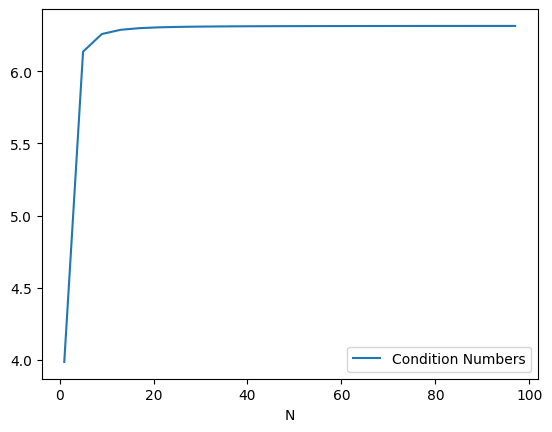

In [4]:
conds = []
n_range = range(1, 101, 4)
# n_range = range(1, 101, 50)
for n in n_range:
    toy_problem_to_json(n, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("N")
plt.plot(n_range, conds, label="Condition Numbers")
plt.legend()

print(conds[0])
print(conds[-1])

5.236307758705363


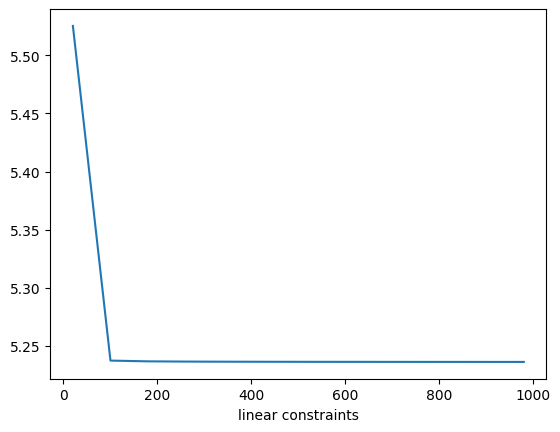

In [19]:
conds = []
lin_cons_range = range(20, 1001, 80)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])

In [6]:
for x_bounds in true_false:
    toy_problem_to_json(N, x_bounds, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    print(f"x_bounds: {x_bounds}, cond number: {condition_number_nes_basic()}")


x_bounds: True, cond number: 6.304036179278167
x_bounds: False, cond number: 6.304036179278167


In [7]:
for bound_below in true_false:
    for bound_above in true_false:
        toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                            EPS, DELTA, LX, LP, LF, UP)
        quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                    bound_below, bound_above)
        print(f"surrogate bound below: {bound_below}, surrogate bound above: {bound_above}, cond number: {condition_number_nes_basic()}")


surrogate bound below: True, surrogate bound above: True, cond number: 6.304036179278167
surrogate bound below: True, surrogate bound above: False, cond number: 6.304036179278167
surrogate bound below: False, surrogate bound above: True, cond number: 6.304036179278167
surrogate bound below: False, surrogate bound above: False, cond number: 6.304036179278167


In [8]:
for surrogate_coefficient in true_false:
    toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, surrogate_coefficient,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    print(f"coefficient in surrogate: {surrogate_coefficient}, cond number: {condition_number_nes_basic()}")


coefficient in surrogate: True, cond number: 6.304036179278167
coefficient in surrogate: False, cond number: 9.280203994880852


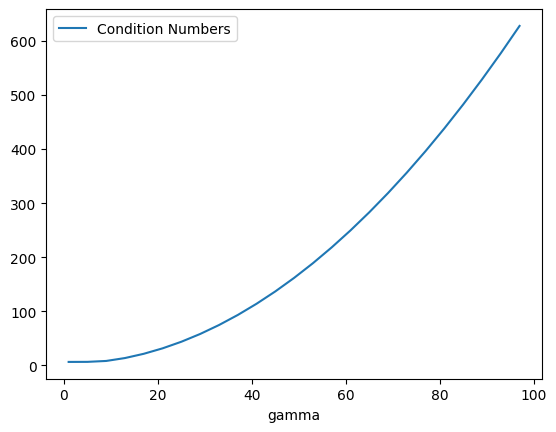

In [9]:
conds = []
gamma_range = range(1, 101, 4)
# gamma_range = range(1, 1001, 40)
for gamma in gamma_range:
    toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, gamma, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("gamma")
plt.plot(gamma_range, conds, label="Condition Numbers")
plt.legend()

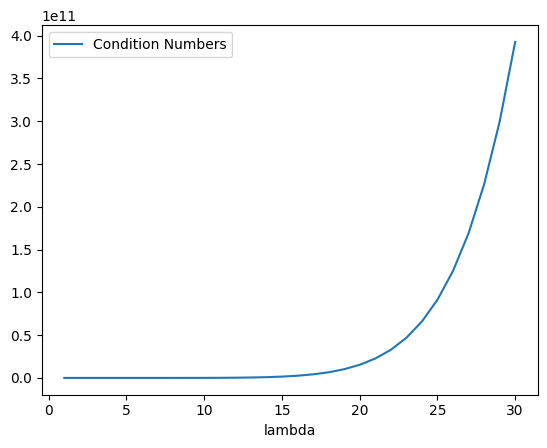

In [10]:
conds = []
lambd_range = range(1, 31)
# lambd_range = range(1, 101, 4)
for lambd in lambd_range:
    toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, lambd,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("lambda")
plt.plot(lambd_range, conds, label="Condition Numbers")
plt.legend()

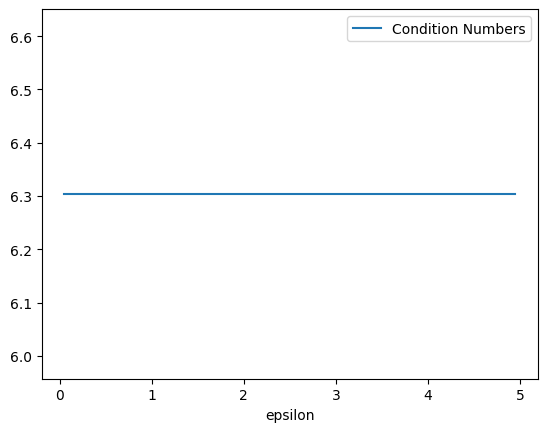

In [11]:
conds = []
epsilon_range = np.arange(.05, 5, .05)
for epsilon in epsilon_range:
    toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        epsilon, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("epsilon")
plt.plot(epsilon_range, conds, label="Condition Numbers")
plt.legend()

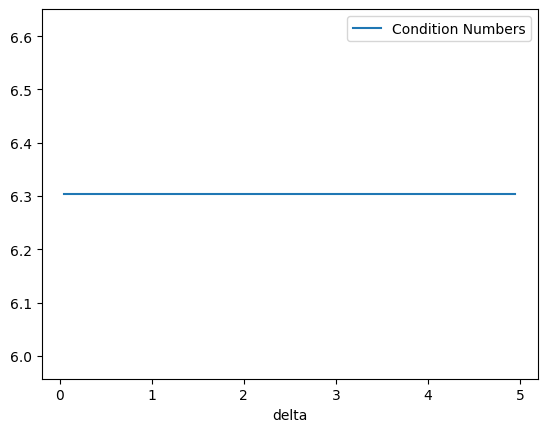

In [12]:
conds = []
delta_range = np.arange(.05, 5, .05)
for delta in delta_range:
    toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, delta, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("delta")
plt.plot(delta_range, conds, label="Condition Numbers")
plt.legend()

In [13]:
print(condition_number(f_name="Model11_lp.json"))
print(condition_number_no_bounds(f_name="Model11_lp.json"))
print(condition_number_nes_basic(f_name="Model11_lp.json"))

68.88068124696944
756.3648894450014
4744.5482490467


22060735.292181052
214202209.95045108


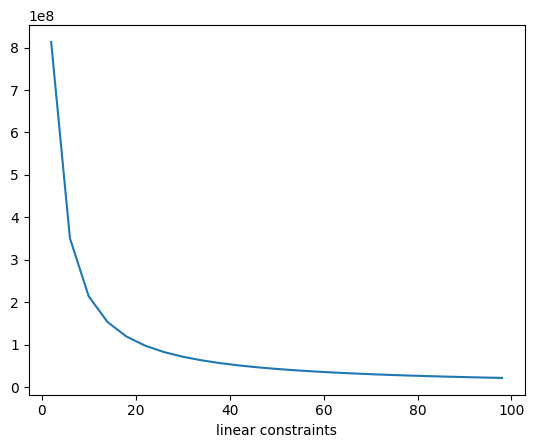

In [ ]:
conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False,
    #                             f_name="model11_quad.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=False,
                                        f_name="model11_quad.json")
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])
print(conds[2])

In [15]:
quadratic_model_lin_approx(10, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                False, True,
                                f_name="model11_quad.json")
condition_number_nes_basic(verbose=False)

np.float64(215038764.97029662)

In [16]:
quadratic_lin_approx_no_surrogate(10, False,
                                f_name="model11_quad.json")
condition_number_nes_basic(verbose=False)

np.float64(214202209.95045108)

75.19976286302578
104.05617319609908


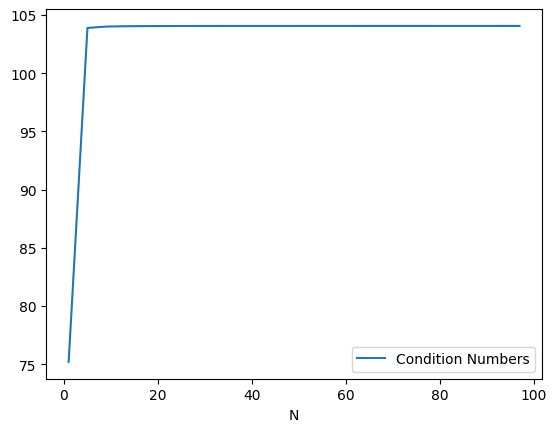

In [17]:
conds = []
n_range = range(1, 101, 4)
# n_range = range(1, 101, 50)
for n in n_range:
    toy_problem_to_json(n, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("N")
plt.plot(n_range, conds, label="Condition Numbers")
plt.legend()

print(conds[0])
print(conds[-1])